# Brain MRI Tissue Segmentation — Multi-Class Semantic Segmentation
## VGG19 + UNet | 4-Class (Background / CSF / Grey Matter / White Matter) | MRBrainS18 Dataset

**Dataset:** MRBrainS18 Challenge Dataset — 7 labeled training subjects, multi-sequence MRI (T1, FLAIR, IR). Only the `training` split is used since the `test` split has no publicly released segmentation labels.

**Label Remapping:** MRBrainS18 uses 9 classes which are consolidated into 4 tissue classes:
- 0 → Background
- 1, 2, 8 → Grey Matter (cortical GM + basal ganglia + brainstem/cerebellum)
- 3, 4 → White Matter (WM + WM lesions)
- 5, 6, 7 → CSF (ventricular CSF + vessels + external CSF)

**Training Notes:**
- Only 7 labeled subjects are available; therefore, every slice (`step=1`) is used to maximize the training dataset.
- Strong data augmentation is applied to improve model generalization.
- EarlyStopping is disabled so the model trains for the full configured number of epochs.

## 1. Import Libraries

In [32]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, UpSampling2D, concatenate,
    BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import VGG19
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [33]:
# ─── Paths ────────────────────────────────────────────────────────────────────
TRAIN_ROOT = '/kaggle/input/datasets/maheswarimudadla/training/training'
# Note: test split excluded — no public segmentation labels available

PROCESSED_DIR  = 'mrbrains_processed'
IMAGE_FOLDER   = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER    = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR  = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR   = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR  = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 8    # smaller batch — fewer total slices than OASIS/IBSR
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.20  # slightly larger test split given small dataset
NUM_CLASSES = 4
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

# ─── MRBrainS18 label remapping ───────────────────────────────────────────────
# Original 9 classes → 4 standard tissue classes (matches OASIS-1 and IBSR)
MRBRAINS_REMAP = {
    0: 0,  # Background
    1: 2,  # Cortical Grey Matter → GM
    2: 2,  # Basal Ganglia → GM
    3: 3,  # White Matter → WM
    4: 3,  # White Matter Lesions → WM
    5: 1,  # Ventricular CSF → CSF
    6: 1,  # Vessels/Choroid Plexus → CSF
    7: 1,  # External CSF/Sulci → CSF
    8: 2,  # Brainstem + Cerebellum → GM
}

print('Config set ✓')
print('Label remapping:', MRBRAINS_REMAP)

Config set ✓
Label remapping: {0: 0, 1: 2, 2: 2, 3: 3, 4: 3, 5: 1, 6: 1, 7: 1, 8: 2}


## 3. Extract 2D Slices — Remap 9 Classes to 4

In [34]:
for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready ✓')

Directories ready ✓


In [35]:
def normalize_slice(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def remap_labels(seg_arr, remap_dict):
    """Remap integer label array using a dictionary mapping."""
    out = np.zeros_like(seg_arr, dtype=np.uint8)
    for orig_label, new_label in remap_dict.items():
        out[seg_arr == orig_label] = new_label
    return out


def extract_slices_mrbrains(subject_dir, subject_name, img_out, mask_out, step=1):
    """
    MRBrainS18 file structure:
      <subject>/orig/reg_T1.nii    — Registered T1 scan
      <subject>/segm.nii           — Segmentation mask
    Both have shape (240, 240, 48).
    """

    # ---------- CHANGED HERE ----------
    t1_path = os.path.join(subject_dir, "orig", "reg_T1.nii")
    seg_path = os.path.join(subject_dir, "segm.nii")

    if not os.path.exists(t1_path):
        t1_path = os.path.join(subject_dir, "orig", "reg_T1.nii.gz")

    if not os.path.exists(seg_path):
        seg_path = os.path.join(subject_dir, "segm.nii.gz")

    if not os.path.exists(t1_path) or not os.path.exists(seg_path):
        print(f"Skipping {subject_name} — missing reg_T1.nii or segm.nii")
        return 0
    # ----------------------------------

    brain_vol = np.squeeze(nib.load(t1_path).get_fdata())
    seg_vol = np.squeeze(nib.load(seg_path).get_fdata())

    print(f"{subject_name} → brain: {brain_vol.shape}, seg: {seg_vol.shape}")

    saved = 0

    for i in range(0, brain_vol.shape[2], step):

        b_sl = brain_vol[:, :, i]
        seg_sl = seg_vol[:, :, i]

        if b_sl.max() == 0:
            continue

        img_arr = normalize_slice(b_sl)

        mask_arr = remap_labels(
            np.round(seg_sl).astype(int),
            MRBRAINS_REMAP
        )

        fname = f"{subject_name}_sl{i:03d}.png"

        cv2.imwrite(os.path.join(img_out, fname), img_arr)
        cv2.imwrite(os.path.join(mask_out, fname), mask_arr)

        saved += 1

    return saved


# ─── Clear old slices ──────────────────────────────────────────────────────────
for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)


# ─── Extract from all 7 training subjects ──────────────────────────────────────
subject_folders = sorted([
    d for d in os.listdir(TRAIN_ROOT)
    if os.path.isdir(os.path.join(TRAIN_ROOT, d))
])

print(f"Found {len(subject_folders)} labeled training subjects: {subject_folders}\n")

total_slices = 0

for subj_name in tqdm(subject_folders, desc="Extracting slices"):

    subj_dir = os.path.join(TRAIN_ROOT, subj_name)

    total_slices += extract_slices_mrbrains(
        subj_dir,
        subj_name,
        IMAGE_FOLDER,
        MASK_FOLDER,
        step=1
    )

print(f"\nTotal slices extracted : {total_slices}")
print(f"Images saved           : {len(os.listdir(IMAGE_FOLDER))}")
print(f"Masks saved            : {len(os.listdir(MASK_FOLDER))}")

Found 7 labeled training subjects: ['1', '14', '27', '29', '4', '5', '7']



Extracting slices:   0%|          | 0/7 [00:00<?, ?it/s]

1 → brain: (240, 240, 48), seg: (240, 240, 48)
14 → brain: (240, 240, 48), seg: (240, 240, 48)
27 → brain: (240, 240, 48), seg: (240, 240, 48)
29 → brain: (240, 240, 48), seg: (240, 240, 48)
4 → brain: (240, 240, 48), seg: (240, 240, 48)
5 → brain: (240, 240, 48), seg: (240, 240, 48)
7 → brain: (240, 240, 48), seg: (240, 240, 48)

Total slices extracted : 336
Images saved           : 336
Masks saved            : 336


## 4. Verify Label Remapping & Visualize

In [36]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')

Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


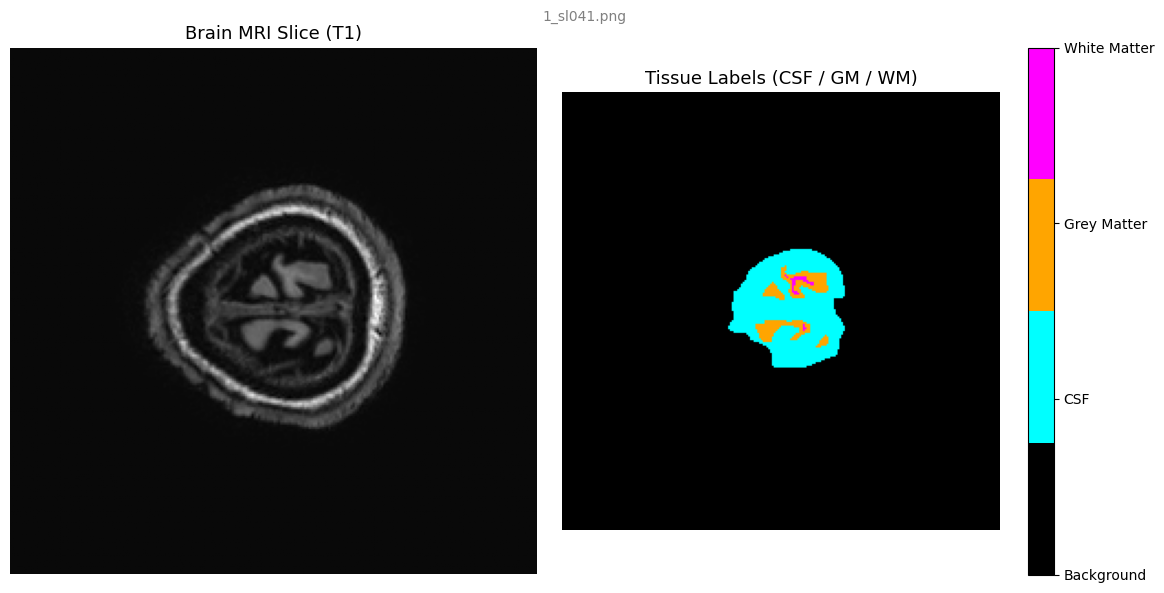

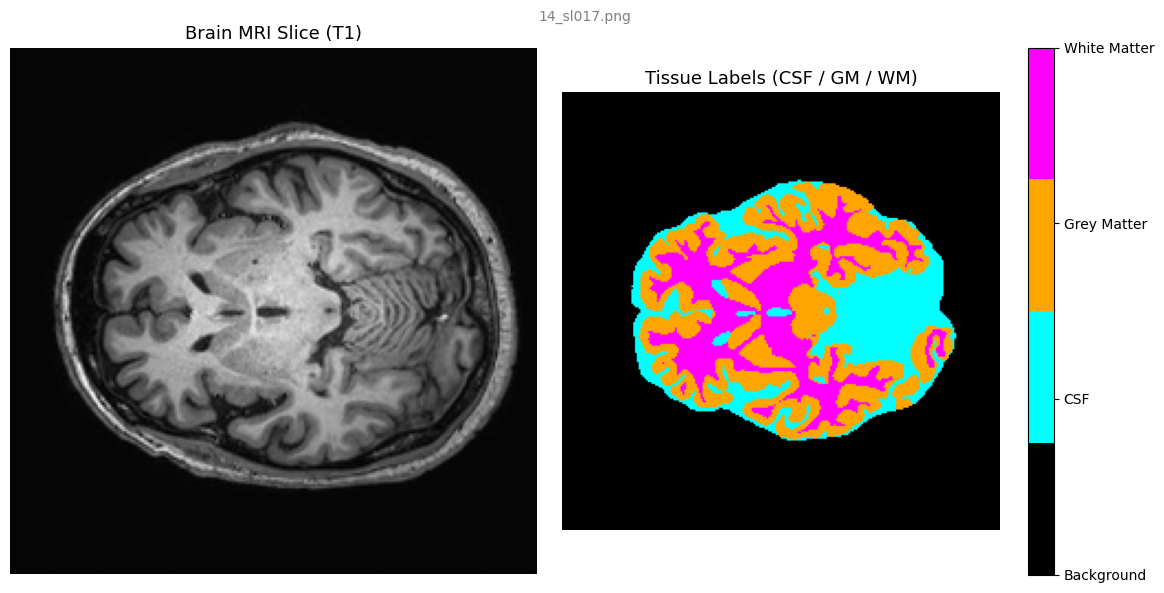

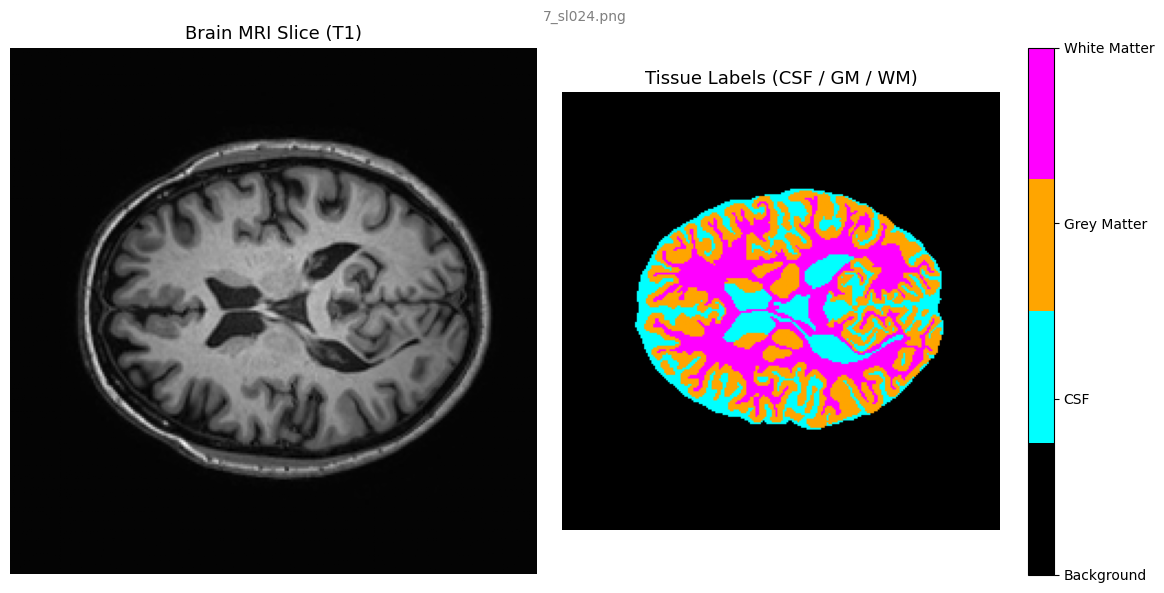

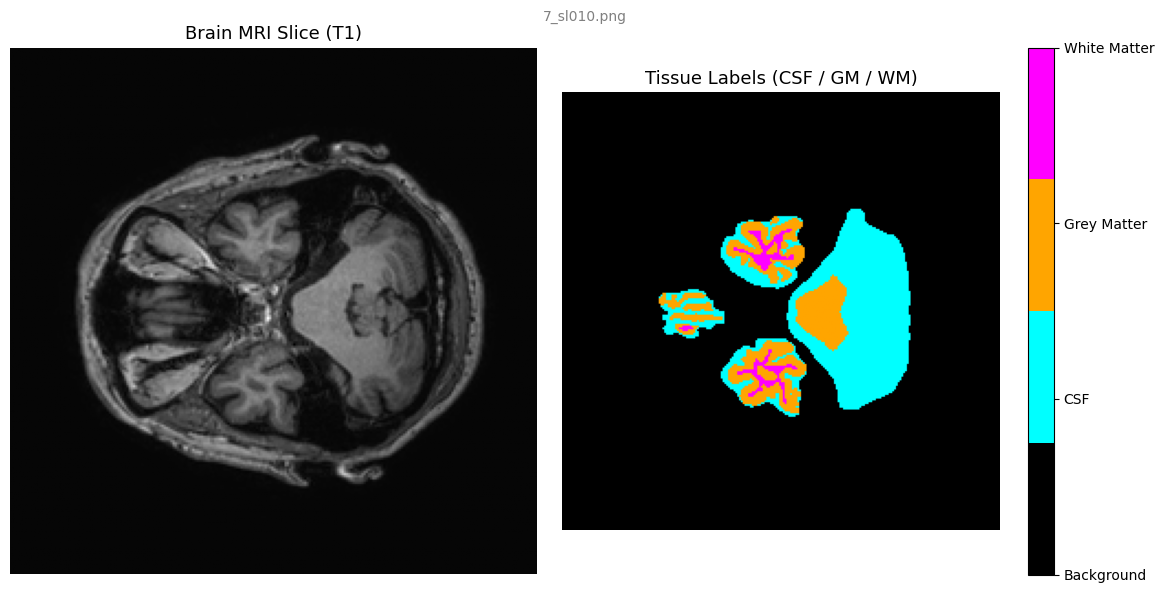

In [37]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample(image_name):
    img  = cv2.imread(os.path.join(IMAGE_FOLDER, image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(MASK_FOLDER,  image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Brain MRI Slice (T1)', fontsize=13)

    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)

    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [38]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch!'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 268  |  Test: 68


  0%|          | 0/268 [00:00<?, ?it/s]

  0%|          | 0/68 [00:00<?, ?it/s]

Files copied ✓


## 6. tf.data Pipeline — with stronger augmentation (small dataset)

In [39]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)
    return img, mask


def augment(img, mask):
    # Stronger augmentation since dataset is small (7 subjects)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes → images:', imgs.shape, ' masks:', masks.shape)

Datasets ready ✓
Batch shapes → images: (8, 224, 224, 3)  masks: (8, 224, 224, 4)


## 7. Model — VGG19 Encoder + UNet Decoder, 4-class softmax output
**VGG19 has 4 conv layers per block in blocks 3-5** instead of VGG16's 3 — deeper encoder, ~20M base params.

In [40]:
def conv_block(x, filters, name_prefix):
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c1')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = Activation('relu', name=f'{name_prefix}_act1')(x)
    x = Conv2D(filters, (3,3), padding='same', name=f'{name_prefix}_c2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = Activation('relu', name=f'{name_prefix}_act2')(x)
    return x

def decoder_block(x, skip, filters, name_prefix):
    x = UpSampling2D((2,2), name=f'{name_prefix}_up')(x)
    x = concatenate([x, skip], name=f'{name_prefix}_cat')
    x = Dropout(0.2, name=f'{name_prefix}_drop')(x)
    x = conv_block(x, filters, name_prefix)
    return x

def build_model(input_shape=(224,224,3), num_classes=4, freeze_encoder=True):
    inputs = Input(shape=input_shape, name='input')
    base = VGG19(include_top=False, weights='imagenet', input_tensor=inputs)
    if freeze_encoder:
        for layer in base.layers: layer.trainable = False
    s1=base.get_layer('block1_conv2').output
    s2=base.get_layer('block2_conv2').output
    s3=base.get_layer('block3_conv4').output
    s4=base.get_layer('block4_conv4').output
    b =base.get_layer('block5_conv4').output
    d4=decoder_block(b,  s4,512,'dec4')
    d3=decoder_block(d4, s3,256,'dec3')
    d2=decoder_block(d3, s2,128,'dec2')
    d1=decoder_block(d2, s1, 64,'dec1')
    output=Conv2D(num_classes,(1,1),activation='softmax',name='output')(d1)
    return Model(inputs=inputs,outputs=output,name='VGG19_UNet_MultiClass_MRBrainS18')

model=build_model(input_shape=(*IMG_SIZE,3),num_classes=NUM_CLASSES)
print('Model built')
print(f'Total parameters     : {model.count_params():,}')
print(f'Trainable parameters : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Model built
Total parameters     : 30,208,708
Trainable parameters : 10,180,484


## 8. Custom Metrics & Loss

In [41]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    return K.mean((2.0 * intersection + smooth) / (union + smooth))

def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)

def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    return K.mean((intersection + smooth) / (total + smooth))

def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def pixel_accuracy_multiclass(y_true, y_pred):
    return K.mean(K.cast(K.equal(K.argmax(y_true, axis=-1), K.argmax(y_pred, axis=-1)), K.floatx()))

def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass,
             pixel_accuracy_multiclass, csf_iou, gm_iou, wm_iou]
)
print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [42]:
model.summary()
try:
    tf.keras.utils.plot_model(model, to_file='vgg19_unet_mrbrains_architecture.png',
                               show_shapes=True, show_layer_names=True, dpi=64)
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:100])

Model: "VGG19_UNet_MultiClass_MRBrainS18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 224, 224,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 112, 112,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 112, 112,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 112, 112,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 56, 56,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 56, 56,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 56, 56,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 56, 56,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv4        │ (None, 56, 56,    │    590,080 │ block3_conv3[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 28, 28,    │          0 │ block3_conv4[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 28, 28,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 28, 28,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 28, 28,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv4        │ (None, 28, 28,    │  2,359,808 │ block4_conv3[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 14, 14,    │          0 │ block4_conv4[0][

 Total params: 30,208,708 (115.24 MB)

 Trainable params: 10,180,484 (38.84 MB)

 Non-trainable params: 20,028,224 (76.40 MB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [43]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)

def colorize_mask(label_map):
    colors = np.array([[0,0,0],[0,255,255],[255,165,0],[255,0,255]], dtype=np.uint8)
    return colors[np.array(label_map).astype(int)]

def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            fig, axes = plt.subplots(1, 3, figsize=(13, 4))
            axes[0].imshow(imgs[i].numpy());                              axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(decode_mask(masks[i]).numpy())); axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(decode_mask(preds[i]).numpy())); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show()

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_vgg19unet_mrbrains.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed
]
print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


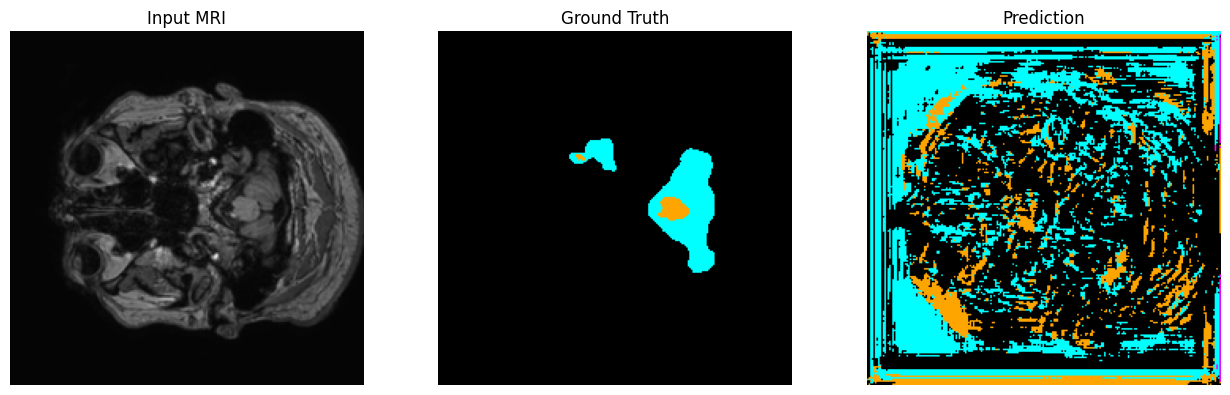

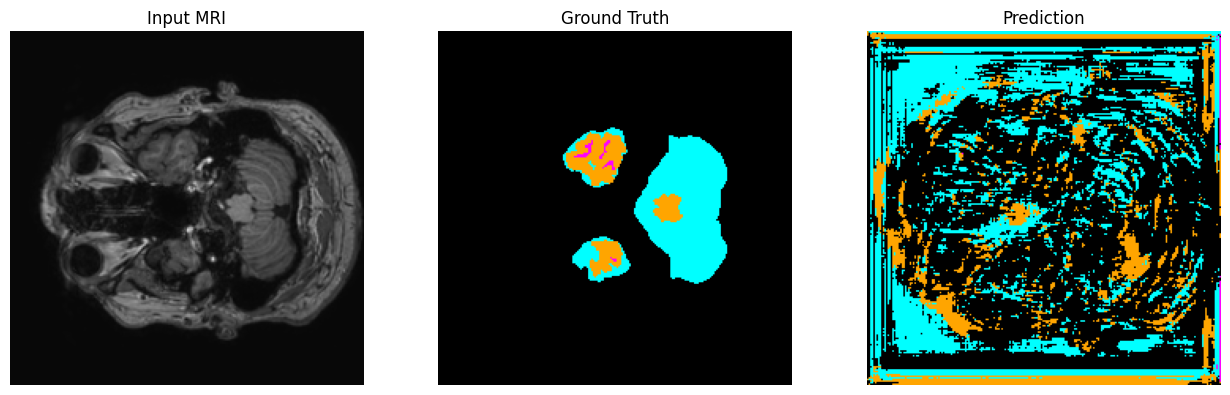

In [44]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 65
Validation steps : 16
Epoch 1/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - csf_iou: 0.0977 - dice_coefficient_multiclass: 0.2588 - gm_iou: 0.0474 - iou_score_multiclass: 0.1715 - loss: 1.8678 - pixel_accuracy_multiclass: 0.6217 - wm_iou: 0.1159
Epoch 1: val_iou_score_multiclass improved from None to 0.16952, saving model to best_model_vgg19unet_mrbrains.keras

Epoch 1: finished saving model to best_model_vgg19unet_mrbrains.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 34s 281ms/step - csf_iou: 0.1160 - dice_coefficient_multiclass: 0.3099 - gm_iou: 0.0436 - iou_score_multiclass: 0.2175 - loss: 1.5827 - pixel_accuracy_multiclass: 0.7639 - wm_iou: 0.1724 - val_csf_iou: 0.1828 - val_dice_coefficient_multiclass: 0.2715 - val_gm_iou: 0.0376 - val_iou_score_multiclass: 0.1695 - val_loss: 4.1049 - val_pixel_accuracy_multiclass: 0.3820 - val_wm_iou: 0.1007 - learning_rate: 1.0000e-04
Epoch 2/100


2026-07-05 19:01:48.605091: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:01:48.849848: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 1/65 ━━━━━━━━━━━━━━━━━━━━ 15:03 14s/step - csf_iou: 0.0087 - dice_coefficient_multiclass: 0.1920 - gm_iou: 4.2287e-05 - iou_score_multiclass: 0.1502 - loss: 1.7381 - pixel_accuracy_multiclass: 0.9411 - wm_iou: 0.0059
Epoch 2: val_iou_score_multiclass did not improve from 0.16952
65/65 ━━━━━━━━━━━━━━━━━━━━ 19s 83ms/step - csf_iou: 0.0087 - dice_coefficient_multiclass: 0.1920 - gm_iou: 4.2287e-05 - iou_score_multiclass: 0.1502 - loss: 1.7381 - pixel_accuracy_multiclass: 0.9411 - wm_iou: 0.0059 - val_csf_iou: 0.1904 - val_dice_coefficient_multiclass: 0.2674 - val_gm_iou: 0.0329 - val_iou_score_multiclass: 0.1680 - val_loss: 4.0762 - val_pixel_accuracy_multiclass: 0.3846 - val_wm_iou: 0.0860 - learning_rate: 1.0000e-04
Epoch 3/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - csf_iou: 0.1494 - dice_coefficient_multiclass: 0.3977 - gm_iou: 0.0700 - iou_score_multiclass: 0.2996 - loss: 1.1086 - pixel_accuracy_multiclass: 0.8826 - wm_iou: 0.2548
Epoch 3: val_iou_score_multiclass improved from 0

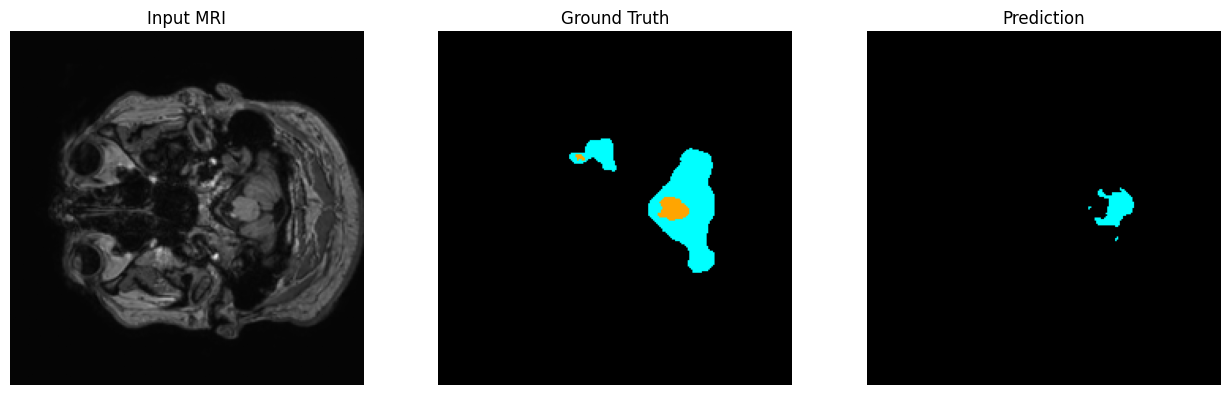

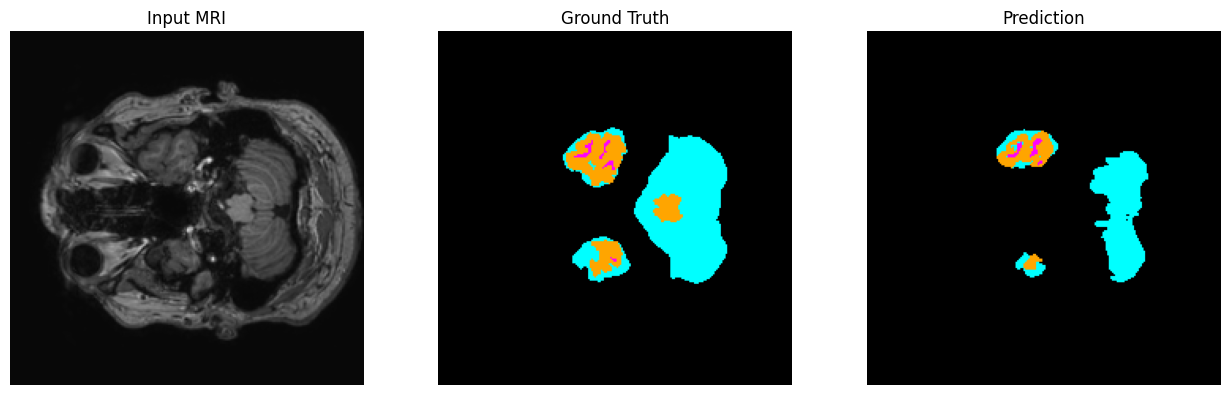

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass did not improve from 0.45932
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - csf_iou: 0.0314 - dice_coefficient_multiclass: 0.2545 - gm_iou: 1.0326e-04 - iou_score_multiclass: 0.2247 - loss: 1.0681 - pixel_accuracy_multiclass: 0.9616 - wm_iou: 0.0208 - val_csf_iou: 0.2533 - val_dice_coefficient_multiclass: 0.5700 - val_gm_iou: 0.1557 - val_iou_score_multiclass: 0.4532 - val_loss: 0.7245 - val_pixel_accuracy_multiclass: 0.9140 - val_wm_iou: 0.5305 - learning_rate: 1.0000e-04
Epoch 11/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - csf_iou: 0.2383 - dice_coefficient_multiclass: 0.5130 - gm_iou: 0.1283 - iou_score_multiclass: 0.4107 - loss: 0.7539 - pixel_accuracy_multiclass: 0.9066 - wm_iou: 0.4075
Epoch 11: val_iou_score_multiclass improved from 0.45932 to 0.48009, saving model to best_model_vgg19unet_mrbrains.keras

Epoch 11: finished saving model to best_model_vgg19unet_mrbrains.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 35s 246ms/step - c

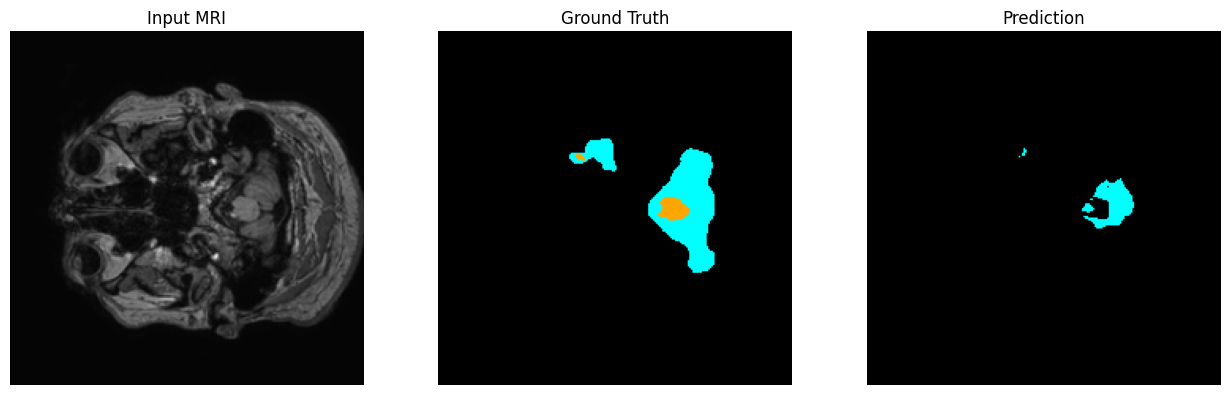

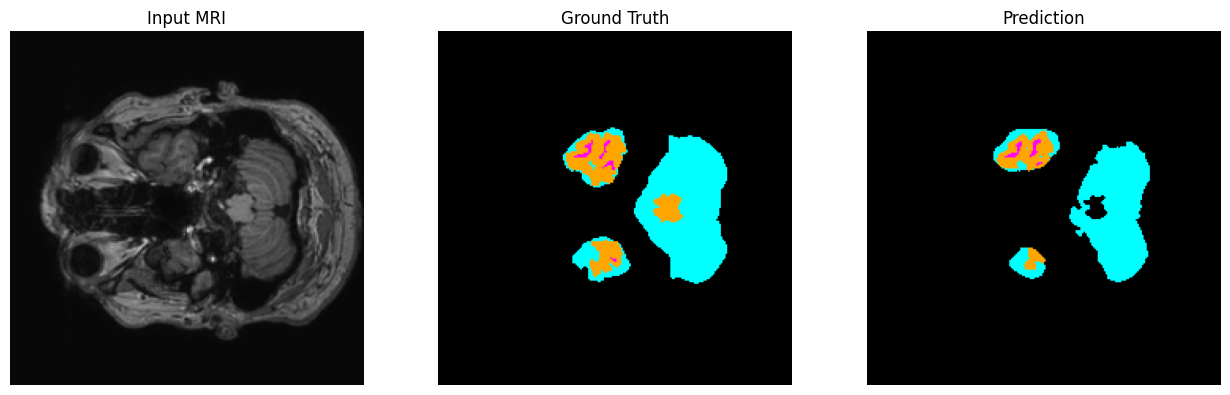

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass did not improve from 0.51575
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - csf_iou: 0.0399 - dice_coefficient_multiclass: 0.2813 - gm_iou: 2.0484e-04 - iou_score_multiclass: 0.2513 - loss: 0.8742 - pixel_accuracy_multiclass: 0.9648 - wm_iou: 0.0487 - val_csf_iou: 0.3084 - val_dice_coefficient_multiclass: 0.6257 - val_gm_iou: 0.1909 - val_iou_score_multiclass: 0.5123 - val_loss: 0.5761 - val_pixel_accuracy_multiclass: 0.9151 - val_wm_iou: 0.6330 - learning_rate: 1.0000e-04
Epoch 21/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - csf_iou: 0.2772 - dice_coefficient_multiclass: 0.5652 - gm_iou: 0.1686 - iou_score_multiclass: 0.4609 - loss: 0.6470 - pixel_accuracy_multiclass: 0.9113 - wm_iou: 0.4887
Epoch 21: val_iou_score_multiclass improved from 0.51575 to 0.51916, saving model to best_model_vgg19unet_mrbrains.keras

Epoch 21: finished saving model to best_model_vgg19unet_mrbrains.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - c

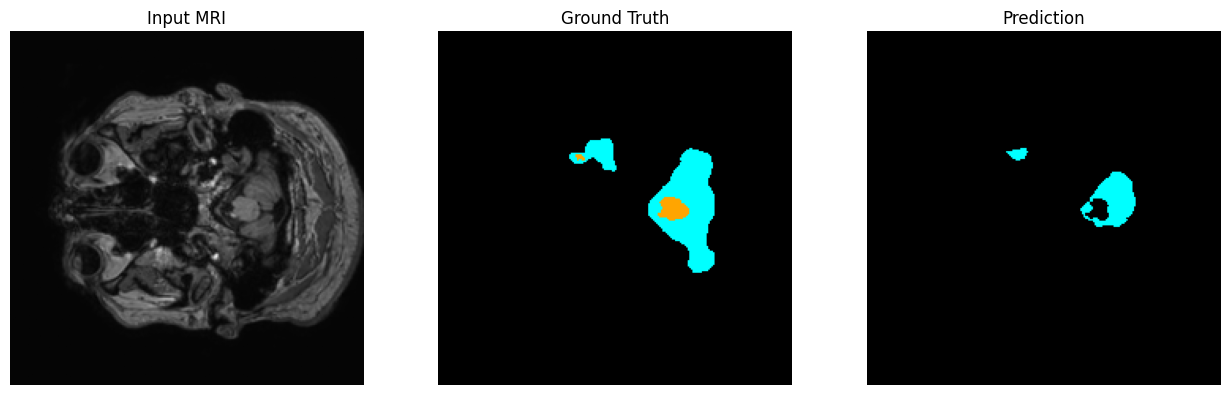

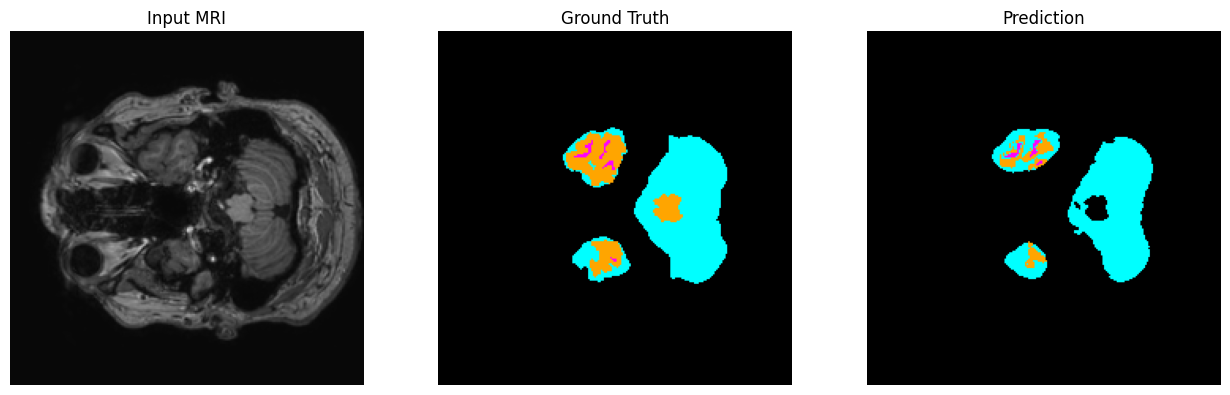

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass did not improve from 0.53655
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - csf_iou: 0.0382 - dice_coefficient_multiclass: 0.3011 - gm_iou: 3.3964e-04 - iou_score_multiclass: 0.2669 - loss: 0.8268 - pixel_accuracy_multiclass: 0.9628 - wm_iou: 0.0880 - val_csf_iou: 0.3320 - val_dice_coefficient_multiclass: 0.6450 - val_gm_iou: 0.2018 - val_iou_score_multiclass: 0.5330 - val_loss: 0.5453 - val_pixel_accuracy_multiclass: 0.9145 - val_wm_iou: 0.6687 - learning_rate: 1.0000e-04
Epoch 31/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - csf_iou: 0.3014 - dice_coefficient_multiclass: 0.5992 - gm_iou: 0.2014 - iou_score_multiclass: 0.4932 - loss: 0.5904 - pixel_accuracy_multiclass: 0.9133 - wm_iou: 0.5442
Epoch 31: val_iou_score_multiclass improved from 0.53655 to 0.53930, saving model to best_model_vgg19unet_mrbrains.keras

Epoch 31: finished saving model to best_model_vgg19unet_mrbrains.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - c

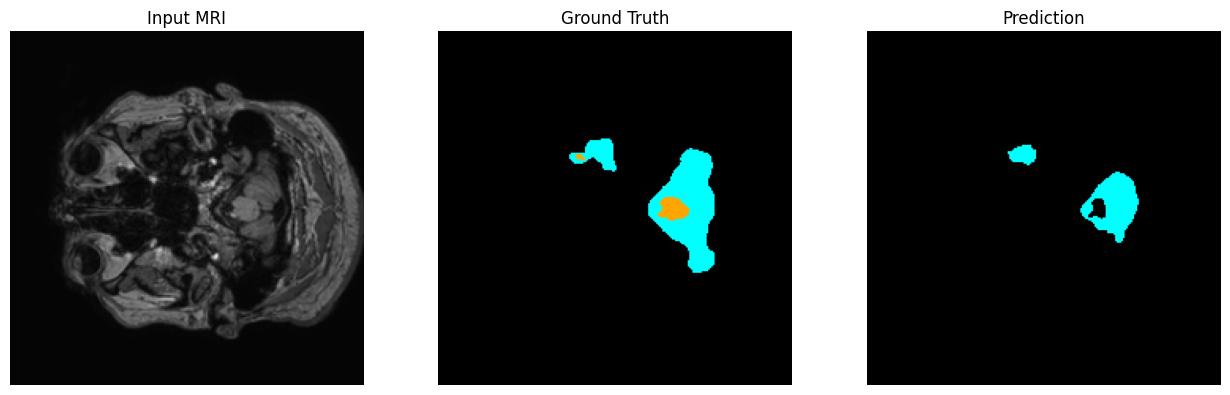

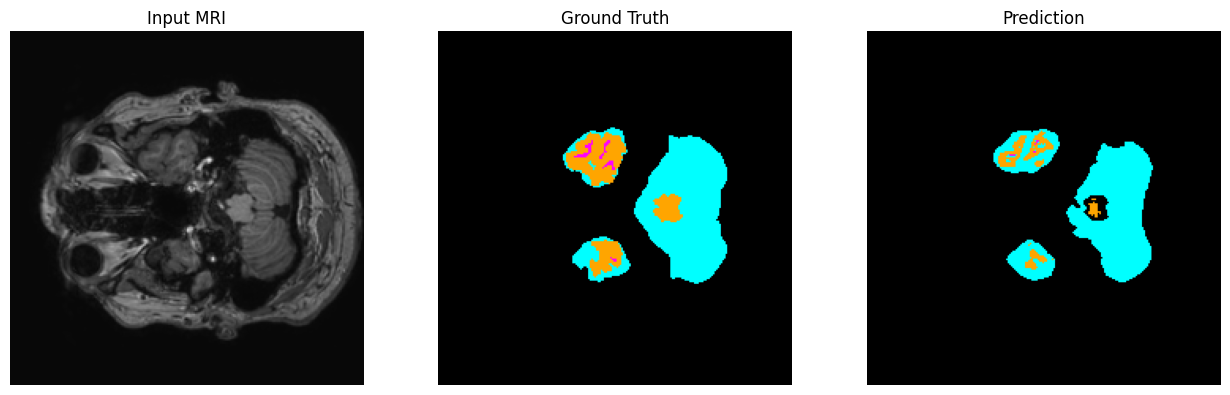

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass did not improve from 0.54603
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 95ms/step - csf_iou: 0.0510 - dice_coefficient_multiclass: 0.3358 - gm_iou: 5.1812e-04 - iou_score_multiclass: 0.2918 - loss: 0.7557 - pixel_accuracy_multiclass: 0.9749 - wm_iou: 0.1535 - val_csf_iou: 0.3310 - val_dice_coefficient_multiclass: 0.6549 - val_gm_iou: 0.2335 - val_iou_score_multiclass: 0.5425 - val_loss: 0.5258 - val_pixel_accuracy_multiclass: 0.9158 - val_wm_iou: 0.6680 - learning_rate: 1.0000e-04
Epoch 41/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - csf_iou: 0.3171 - dice_coefficient_multiclass: 0.6230 - gm_iou: 0.2308 - iou_score_multiclass: 0.5160 - loss: 0.5551 - pixel_accuracy_multiclass: 0.9150 - wm_iou: 0.5822
Epoch 41: val_iou_score_multiclass improved from 0.54603 to 0.54755, saving model to best_model_vgg19unet_mrbrains.keras

Epoch 41: finished saving model to best_model_vgg19unet_mrbrains.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 322ms/step - c

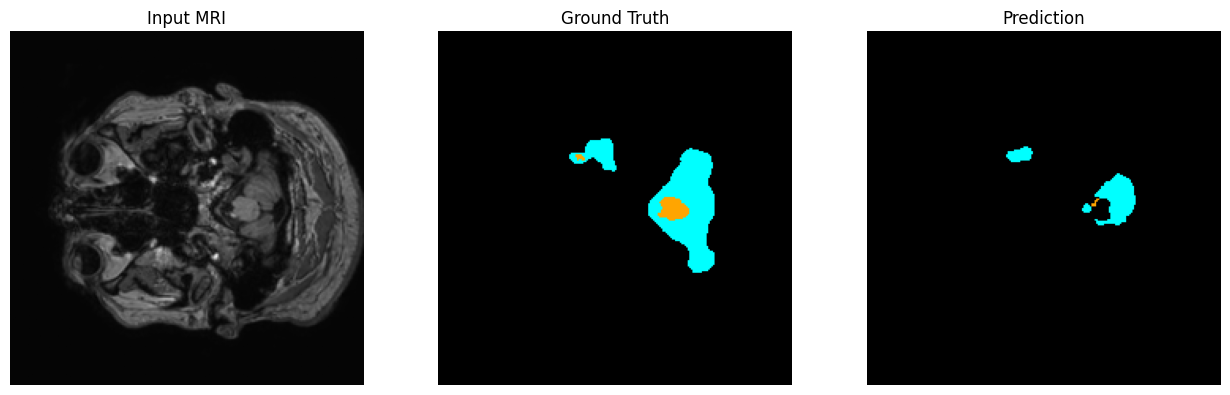

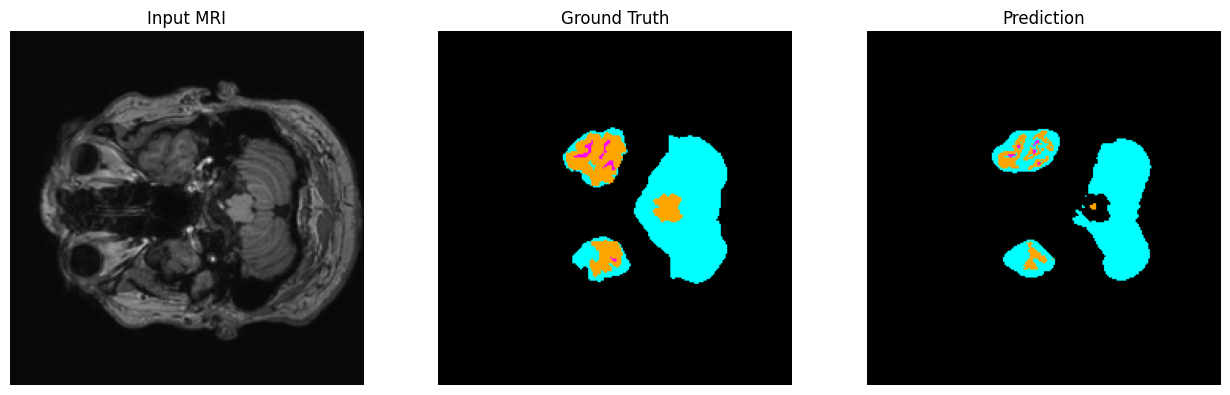

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass did not improve from 0.55338
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 94ms/step - csf_iou: 0.0679 - dice_coefficient_multiclass: 0.3672 - gm_iou: 7.3082e-04 - iou_score_multiclass: 0.3147 - loss: 0.7060 - pixel_accuracy_multiclass: 0.9807 - wm_iou: 0.2167 - val_csf_iou: 0.3320 - val_dice_coefficient_multiclass: 0.6615 - val_gm_iou: 0.2415 - val_iou_score_multiclass: 0.5504 - val_loss: 0.5172 - val_pixel_accuracy_multiclass: 0.9162 - val_wm_iou: 0.6870 - learning_rate: 1.0000e-04
Epoch 51/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - csf_iou: 0.3300 - dice_coefficient_multiclass: 0.6407 - gm_iou: 0.2509 - iou_score_multiclass: 0.5336 - loss: 0.5301 - pixel_accuracy_multiclass: 0.9163 - wm_iou: 0.6154
Epoch 51: val_iou_score_multiclass improved from 0.55338 to 0.55341, saving model to best_model_vgg19unet_mrbrains.keras

Epoch 51: finished saving model to best_model_vgg19unet_mrbrains.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 246ms/step - c

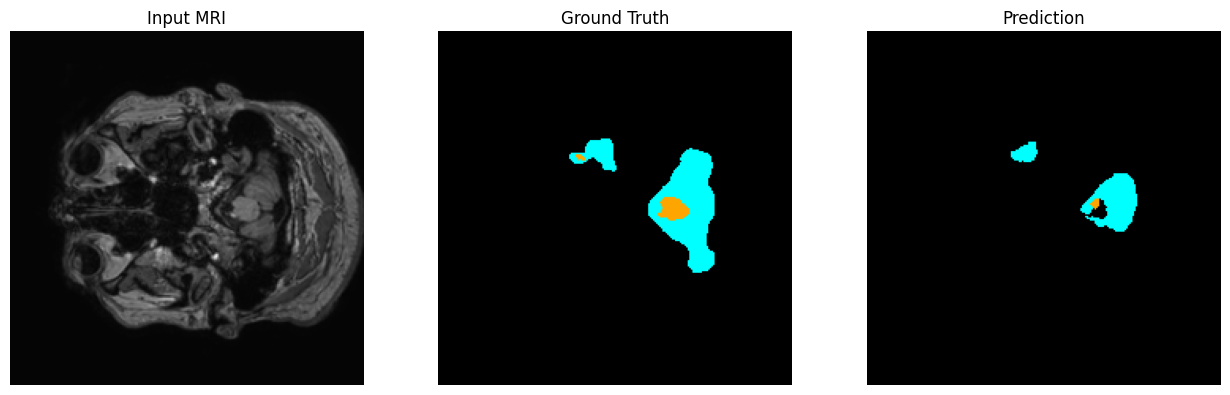

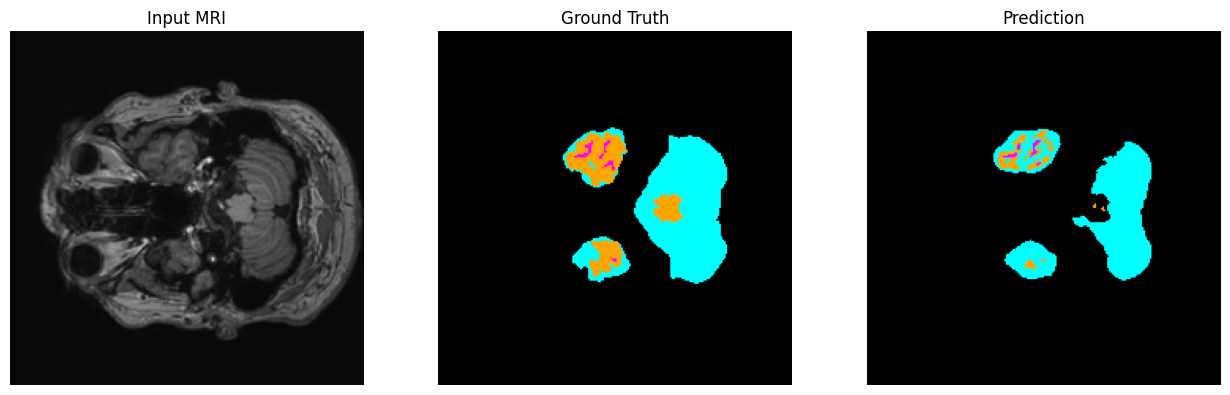

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass did not improve from 0.55948
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - csf_iou: 0.0723 - dice_coefficient_multiclass: 0.3892 - gm_iou: 8.9733e-04 - iou_score_multiclass: 0.3321 - loss: 0.6794 - pixel_accuracy_multiclass: 0.9809 - wm_iou: 0.2773 - val_csf_iou: 0.3338 - val_dice_coefficient_multiclass: 0.6663 - val_gm_iou: 0.2452 - val_iou_score_multiclass: 0.5563 - val_loss: 0.5088 - val_pixel_accuracy_multiclass: 0.9163 - val_wm_iou: 0.7038 - learning_rate: 1.0000e-04
Epoch 61/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - csf_iou: 0.3401 - dice_coefficient_multiclass: 0.6515 - gm_iou: 0.2637 - iou_score_multiclass: 0.5449 - loss: 0.5150 - pixel_accuracy_multiclass: 0.9175 - wm_iou: 0.6348
Epoch 61: val_iou_score_multiclass improved from 0.55948 to 0.56121, saving model to best_model_vgg19unet_mrbrains.keras

Epoch 61: finished saving model to best_model_vgg19unet_mrbrains.keras
65/65 ━━━━━━━━━━━━━━━━━━━━ 16s 249ms/step - c

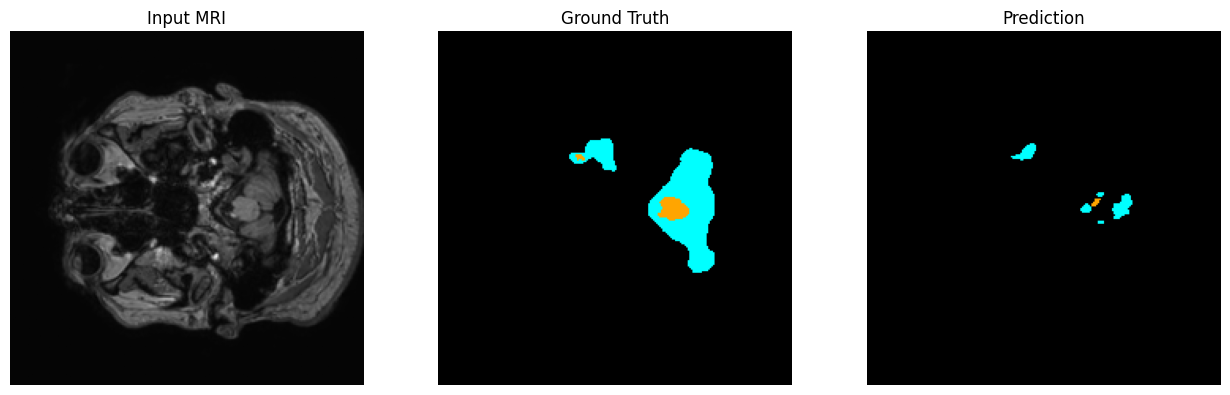

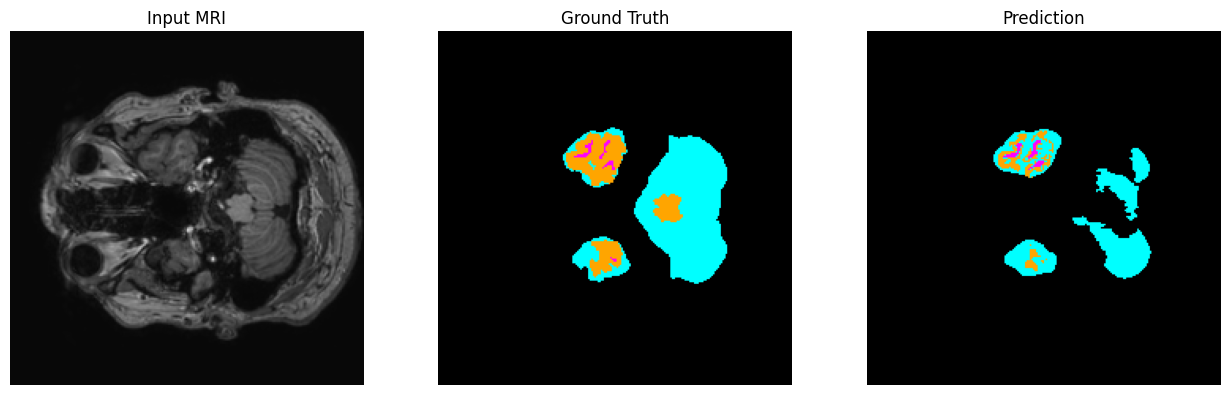

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass did not improve from 0.56121
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - csf_iou: 0.1093 - dice_coefficient_multiclass: 0.4156 - gm_iou: 9.8381e-04 - iou_score_multiclass: 0.3515 - loss: 0.6270 - pixel_accuracy_multiclass: 0.9890 - wm_iou: 0.3101 - val_csf_iou: 0.3297 - val_dice_coefficient_multiclass: 0.6683 - val_gm_iou: 0.2495 - val_iou_score_multiclass: 0.5590 - val_loss: 0.5011 - val_pixel_accuracy_multiclass: 0.9176 - val_wm_iou: 0.7131 - learning_rate: 5.0000e-05
Epoch 71/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - csf_iou: 0.3512 - dice_coefficient_multiclass: 0.6630 - gm_iou: 0.2788 - iou_score_multiclass: 0.5565 - loss: 0.4982 - pixel_accuracy_multiclass: 0.9202 - wm_iou: 0.6528
Epoch 71: val_iou_score_multiclass did not improve from 0.56121
65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 235ms/step - csf_iou: 0.3408 - dice_coefficient_multiclass: 0.6443 - gm_iou: 0.2468 - iou_score_multiclass: 0.5402 - loss: 0.5211 - pixel_accur

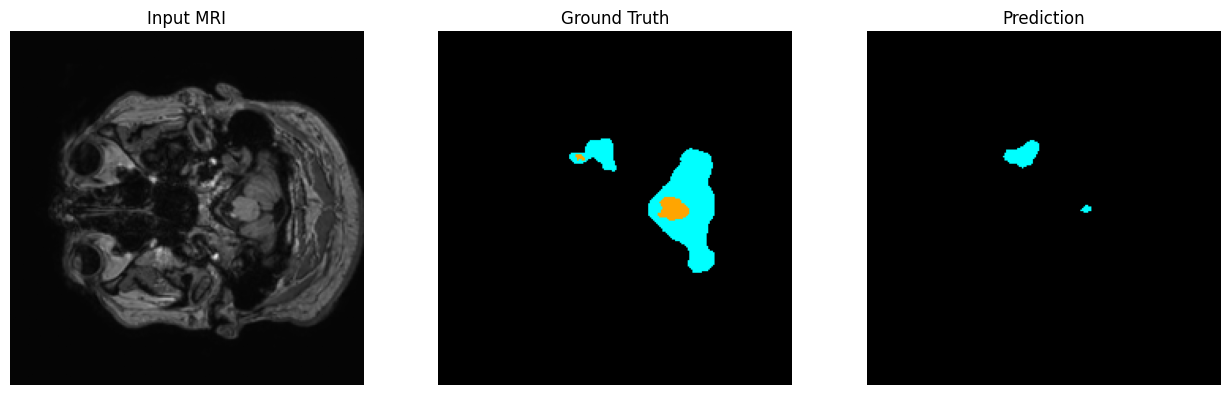

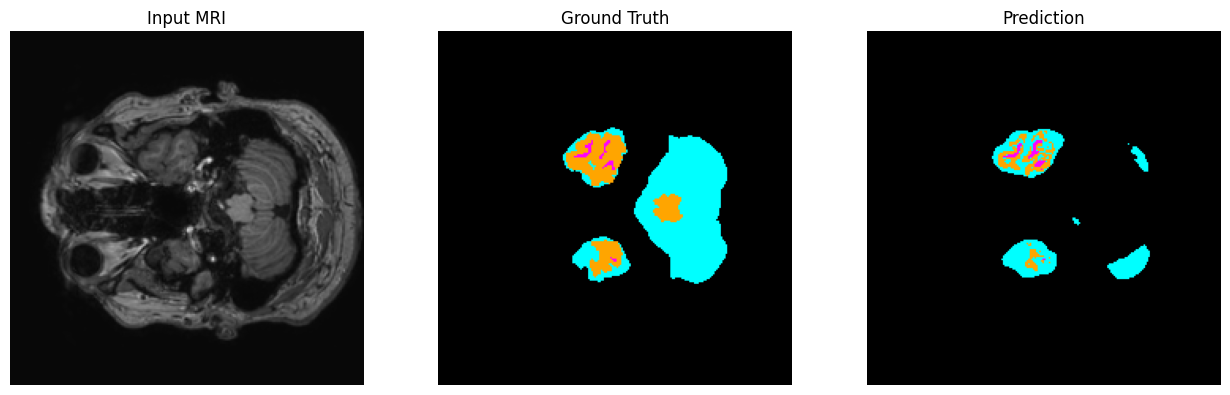

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass did not improve from 0.56366

Epoch 80: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 98ms/step - csf_iou: 0.1862 - dice_coefficient_multiclass: 0.4581 - gm_iou: 0.0013 - iou_score_multiclass: 0.3829 - loss: 0.5775 - pixel_accuracy_multiclass: 0.9909 - wm_iou: 0.3565 - val_csf_iou: 0.3297 - val_dice_coefficient_multiclass: 0.6709 - val_gm_iou: 0.2530 - val_iou_score_multiclass: 0.5622 - val_loss: 0.5015 - val_pixel_accuracy_multiclass: 0.9167 - val_wm_iou: 0.7225 - learning_rate: 2.5000e-05
Epoch 81/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - csf_iou: 0.3620 - dice_coefficient_multiclass: 0.6697 - gm_iou: 0.2852 - iou_score_multiclass: 0.5632 - loss: 0.4873 - pixel_accuracy_multiclass: 0.9225 - wm_iou: 0.6615
Epoch 81: val_iou_score_multiclass improved from 0.56366 to 0.56647, saving model to best_model_vgg19unet_mrbrains.keras

Epoch 81: finished saving model to best_mo

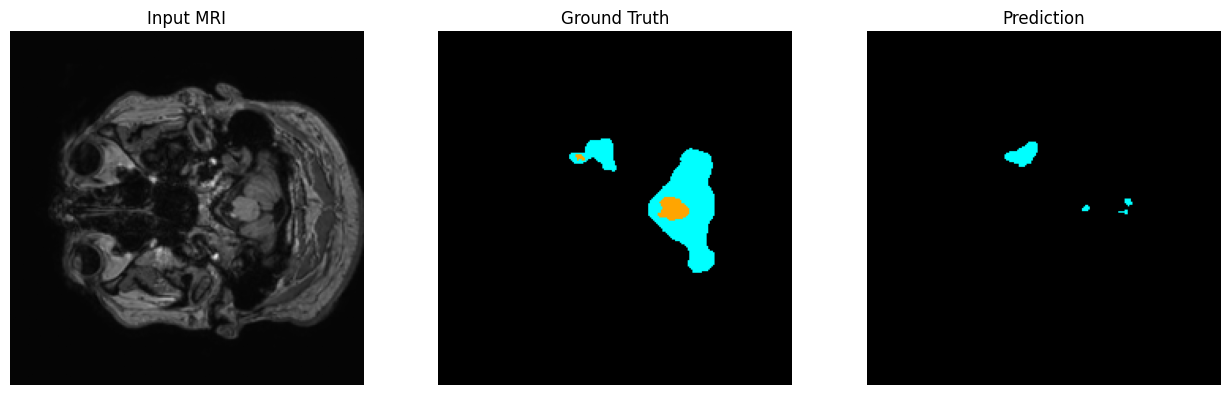

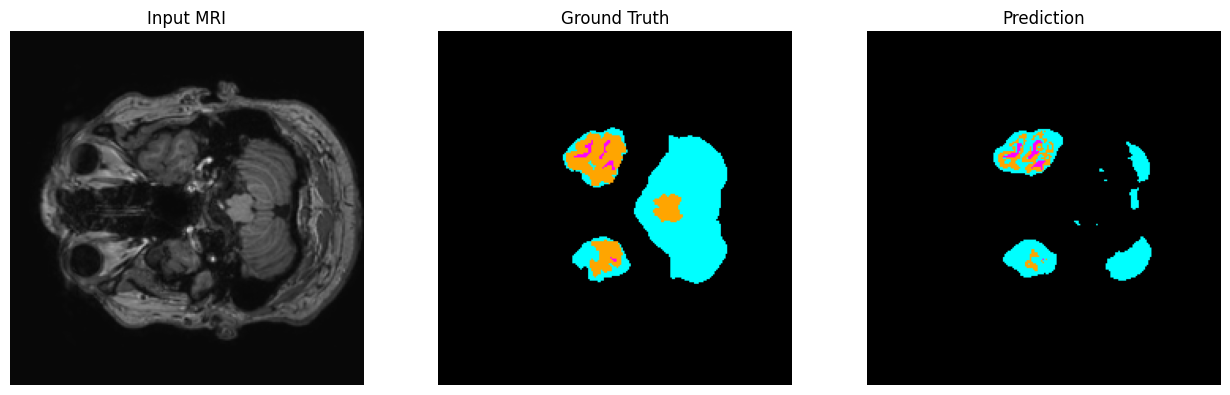

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass did not improve from 0.56740
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - csf_iou: 0.2258 - dice_coefficient_multiclass: 0.4615 - gm_iou: 0.0014 - iou_score_multiclass: 0.3838 - loss: 0.5689 - pixel_accuracy_multiclass: 0.9927 - wm_iou: 0.3194 - val_csf_iou: 0.3340 - val_dice_coefficient_multiclass: 0.6746 - val_gm_iou: 0.2516 - val_iou_score_multiclass: 0.5672 - val_loss: 0.4934 - val_pixel_accuracy_multiclass: 0.9178 - val_wm_iou: 0.7391 - learning_rate: 6.2500e-06
Epoch 91/100
65/65 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - csf_iou: 0.3674 - dice_coefficient_multiclass: 0.6733 - gm_iou: 0.2892 - iou_score_multiclass: 0.5674 - loss: 0.4825 - pixel_accuracy_multiclass: 0.9233 - wm_iou: 0.6679
Epoch 91: val_iou_score_multiclass did not improve from 0.56740
65/65 ━━━━━━━━━━━━━━━━━━━━ 15s 235ms/step - csf_iou: 0.3578 - dice_coefficient_multiclass: 0.6555 - gm_iou: 0.2578 - iou_score_multiclass: 0.5518 - loss: 0.5039 - pixel_accuracy_

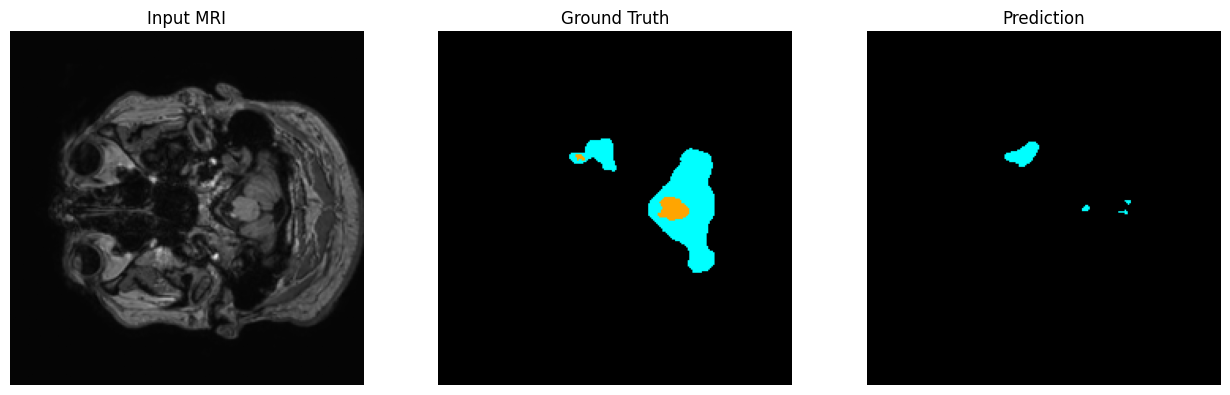

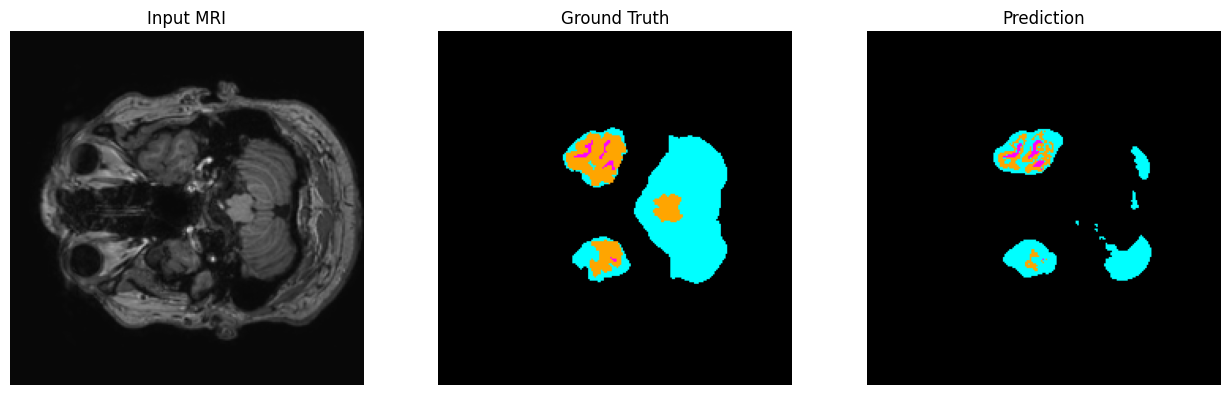

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.56740
65/65 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - csf_iou: 0.2099 - dice_coefficient_multiclass: 0.4579 - gm_iou: 0.0013 - iou_score_multiclass: 0.3813 - loss: 0.5801 - pixel_accuracy_multiclass: 0.9918 - wm_iou: 0.3255 - val_csf_iou: 0.3339 - val_dice_coefficient_multiclass: 0.6747 - val_gm_iou: 0.2523 - val_iou_score_multiclass: 0.5672 - val_loss: 0.4941 - val_pixel_accuracy_multiclass: 0.9176 - val_wm_iou: 0.7386 - learning_rate: 1.5625e-06

Training time: 19.9 min


In [45]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()
history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)
print(f'\nTraining time: {(time.time()-start_time)/60:.1f} min')

## 13. Training Graphs

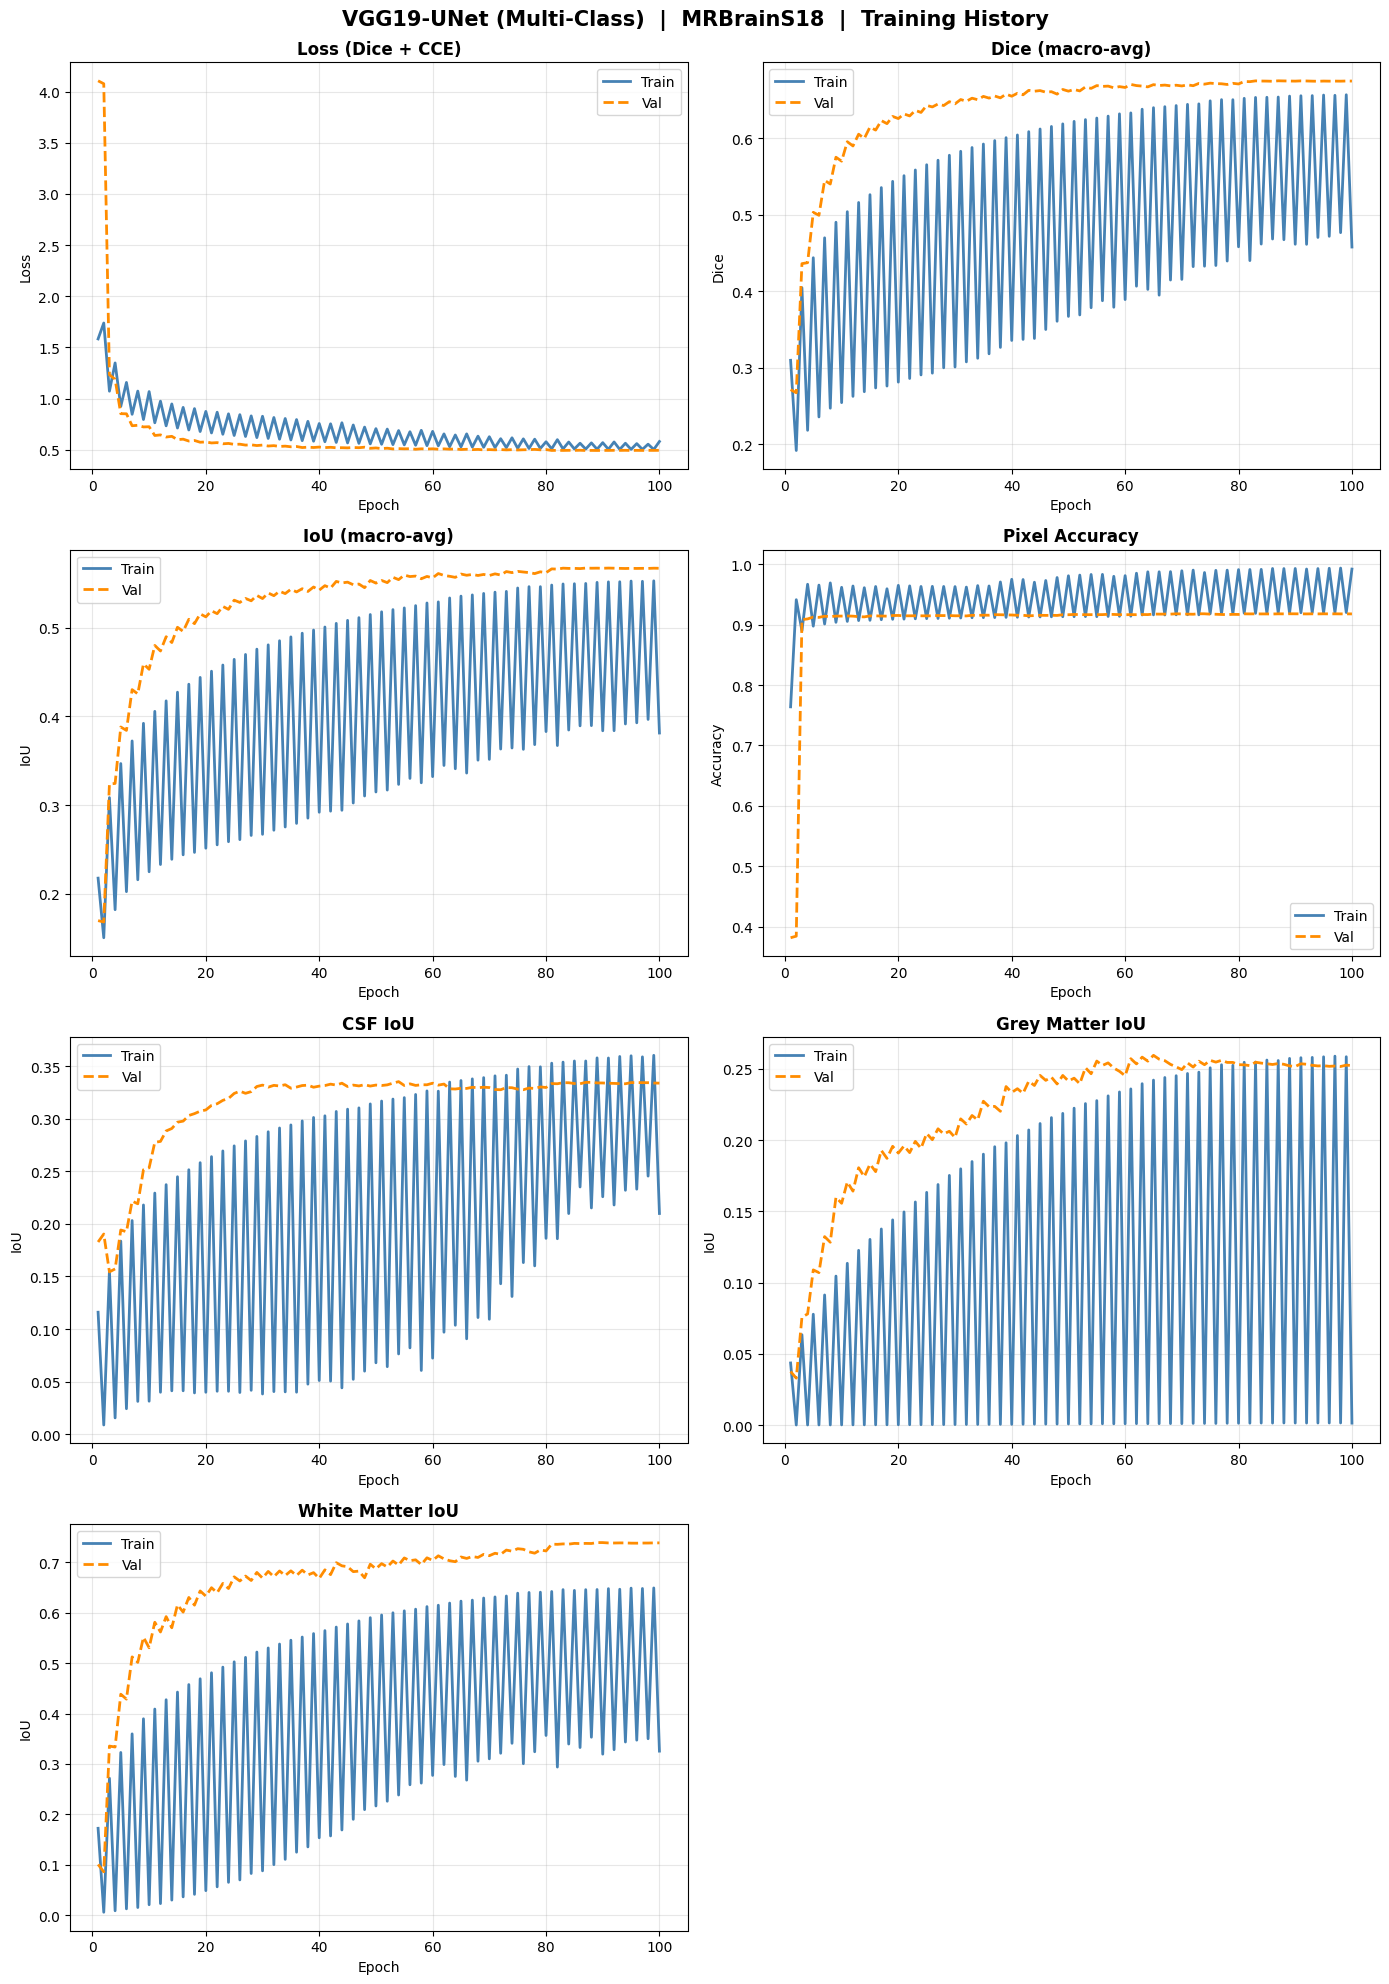

Plot saved ✓


In [46]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('VGG19-UNet (Multi-Class)  |  MRBrainS18  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (tk, vk, title, ylabel) in zip(axes.flatten(), plot_specs):
    er = range(1, len(H[tk]) + 1)
    ax.plot(er, H[tk], label='Train', color='steelblue', linewidth=2)
    ax.plot(er, H[vk], label='Val', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_vgg19_unet_mrbrains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 14. Best & Average Metrics Table

In [47]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  VGG19-UNet Multi-Class  |  MRBrainS18')
print('=' * 68)
print(report.to_string())
print('=' * 68)
best_epoch = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')
report

   BEST & AVERAGE METRICS  —  VGG19-UNet Multi-Class  |  MRBrainS18
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.5021     0.6902    0.4924   0.6231
Dice (macro-avg)      0.6568     0.4781    0.6750   0.6384
IoU (macro-avg)       0.5530     0.4006    0.5674   0.5279
Pixel Accuracy        0.9934     0.9434    0.9179   0.9052
CSF IoU               0.3603     0.1993    0.3353   0.3142
Grey Matter IoU       0.2589     0.1005    0.2595   0.2210
White Matter IoU      0.6492     0.3749    0.7392   0.6619

Best Val IoU (macro-avg): 0.5674  (epoch 87)
Best Val CSF IoU         : 0.3353
Best Val Grey Matter IoU : 0.2595
Best Val White Matter IoU: 0.7392


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.5021,0.6902,0.4924,0.6231
Dice (macro-avg),0.6568,0.4781,0.6750,0.6384
IoU (macro-avg),0.5530,0.4006,0.5674,0.5279
Pixel Accuracy,0.9934,0.9434,0.9179,0.9052
CSF IoU,0.3603,0.1993,0.3353,0.3142
Grey Matter IoU,0.2589,0.1005,0.2595,0.2210
White Matter IoU,0.6492,0.3749,0.7392,0.6619


## 15. Load Best Model & Final Evaluation

In [48]:
best_model = tf.keras.models.load_model(
    'best_model_vgg19unet_mrbrains.keras',
    custom_objects={
        'combined_loss_multiclass': combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass': iou_score_multiclass,
        'pixel_accuracy_multiclass': pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
    }
)
print('Best model loaded ✓')

Best model loaded ✓


In [49]:
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (VGG19-UNet | MRBrainS18)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

pd.DataFrame([{
    'Model': 'VGG19-UNet (MRBrainS18)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')

16/17 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - csf_iou: 0.3375 - dice_coefficient_multiclass: 0.6822 - gm_iou: 0.2625 - iou_score_multiclass: 0.5761 - loss: 0.4805 - pixel_accuracy_multiclass: 0.9212 - wm_iou: 0.7601

2026-07-05 19:21:16.552248: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-07-05 19:21:16.797485: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


17/17 ━━━━━━━━━━━━━━━━━━━━ 11s 460ms/step - csf_iou: 0.3295 - dice_coefficient_multiclass: 0.6717 - gm_iou: 0.2488 - iou_score_multiclass: 0.5642 - loss: 0.4956 - pixel_accuracy_multiclass: 0.9150 - wm_iou: 0.7360

  FINAL TEST-SET METRICS  (VGG19-UNet | MRBrainS18)
  loss                               : 0.4956
  compile_metrics                    : 0.6717


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
VGG19-UNet (MRBrainS18),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

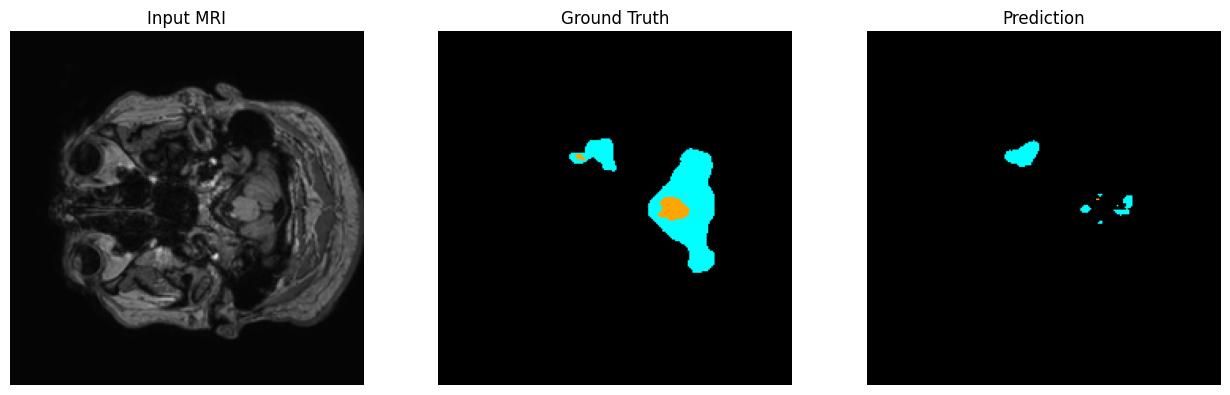

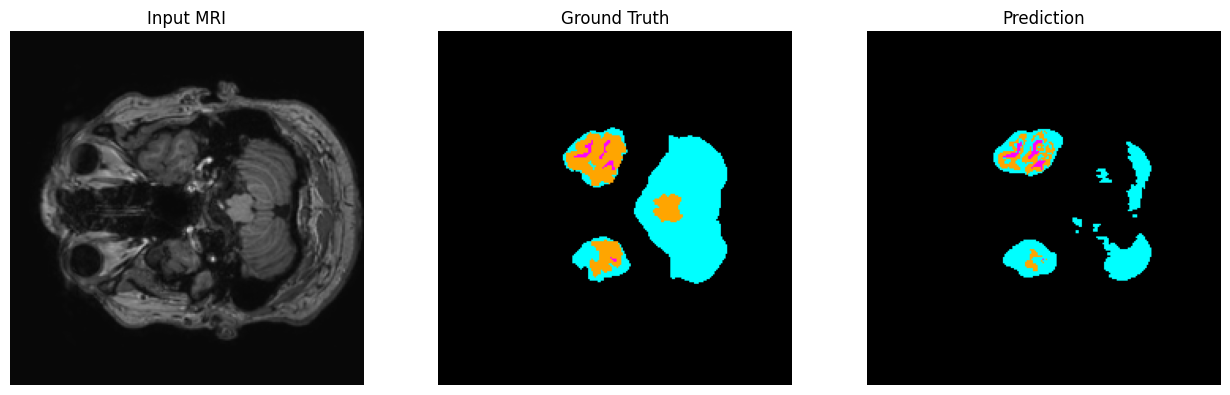

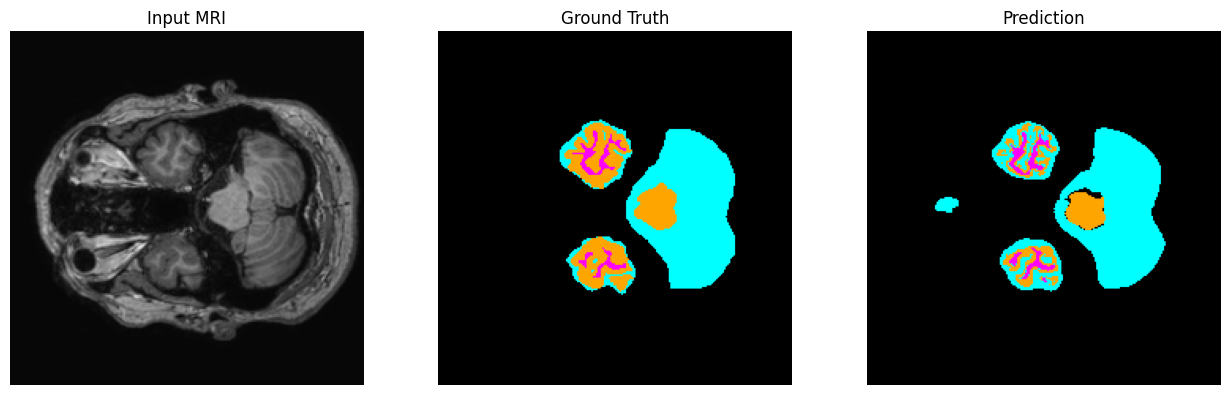

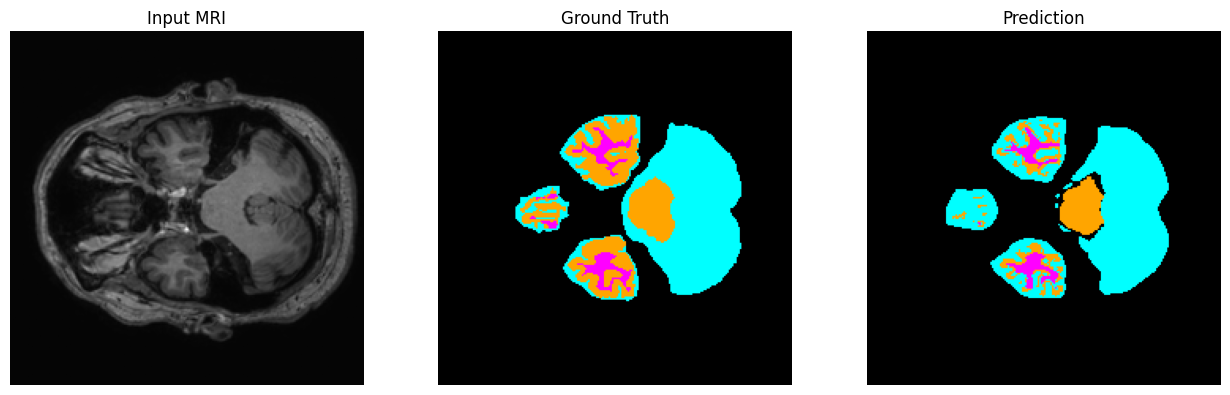

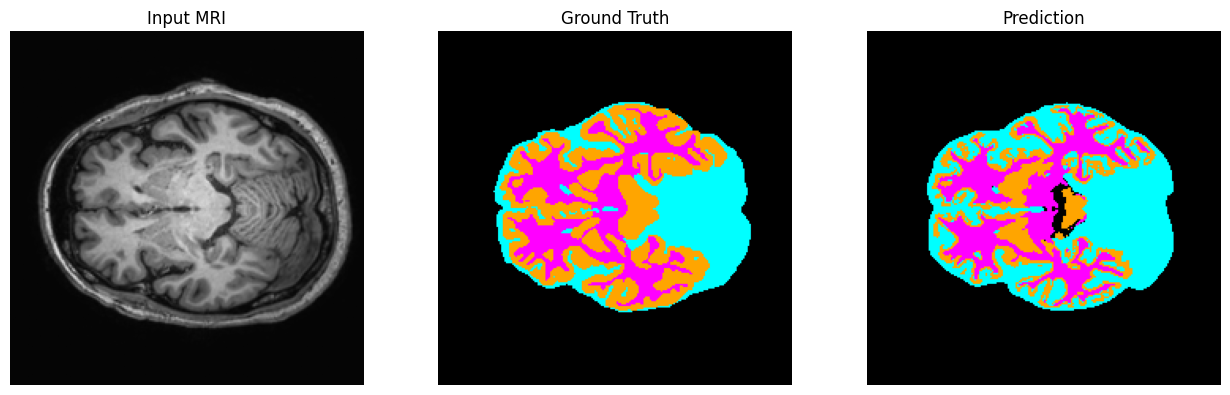

In [50]:
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Save Final Model

In [51]:
best_model.save('mrbrains_vgg19_unet_multiclass_final.keras')
print('Model saved ✓')

Model saved ✓
